<a target="_blank" href="https://colab.research.google.com/github/cesarschoollectures/am-labs/blob/main/assignments/E01_Decision_Tree.ipynb">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Aprendizado de Máquina

Nesta atividade, você irá trabalhar com o dataset Fashion MNIST utilizando modelos de classificação do sklearn.

O foco NÃO é apenas obter bons resultados, mas garantir que o experimento seja:
- correto
- reprodutível
- bem estruturado
- criticamente analisado

# Dicas importantes

## Sobre o dataset (Fashion MNIST)

- Utilize `fetch_openml` do sklearn para carregar os dados
- Use: `as_frame=False`
- Use: `mnist_784`
- Converta os rótulos para inteiro:
  
  ```python
  y = y.astype(int)
  ```

# Questão 1

Implemente uma função load_data(seed) que:

Carregue o dataset `Fashion MNIST`
Realize a separação em treino e teste
Utilize `train_test_split` com controle de aleatoriedade
Retorne: `X_train`, `X_test`, `y_train`, `y_test`

Depois responda: 
É necessário normalizar os dados para esse tipo de modelo? Justifique.

**Solução**:

In [1]:
# TODO: implemente load_data

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report
)
from sklearn.tree import DecisionTreeClassifier

def load_data(seed=42):
    mnist = fetch_openml('mnist_784', version=1, as_frame=False, cache=True)
    X, y = mnist.data, mnist.target.astype(int)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=seed
    )

    return X_train, X_test, y_train, y_test

# Questão 2

Implemente as funções:

`train_random_forest(X_train, y_train, seed)`
`train_adaboost(X_train, y_train, seed)`

## Requisitos:

Utilizar os modelos do `sklearn`
Garantir reprodutibilidade com `random_state`

**Solução**:

In [6]:
# TODO: implemente load_data

def train_random_forest(X_train, y_train, seed=42):
    model = RandomForestClassifier(
        n_estimators=100,
        random_state=seed,
        n_jobs=-1
    )
    model.fit(X_train, y_train)
    return model


def train_adaboost(X_train, y_train, seed=42):
    base_estimator = DecisionTreeClassifier(max_depth=2, random_state=seed)
    model = AdaBoostClassifier(
        estimator=base_estimator,
        n_estimators=100,
        random_state=seed
    )
    model.fit(X_train, y_train)
    return model

# Questão 3

Implemente a função:

- `evaluate(model, X_test, y_test)`

Ela deve:
- Realizar predições
- Retornar a acurácia do modelo

**Solução**:

In [7]:
# TODO: implemente load_data

def evaluate(model, X_test, y_test):
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    return accuracy

**Adicione seu texto de solução aqui**.

# Questão 4

Implemente a função:

- `run_pipeline(model_type="rf", seed=42)`

Ela deve:
- Carregar os dados
- Treinar o modelo escolhido (`rf` ou `ab`)
- Avaliar o modelo
- Retornar a acurácia

**Solução**:

In [8]:
# TODO: implemente load_data

def run_pipeline(model_type="rf", seed=42):
    X_train, X_test, y_train, y_test = load_data(seed=seed)

    if model_type == "rf":
        model = train_random_forest(X_train, y_train, seed=seed)
    elif model_type == "ab":
        model = train_adaboost(X_train, y_train, seed=seed)
    else:
        raise ValueError(f"model_type inválido: '{model_type}'. Use 'rf' ou 'ab'.")

    accuracy = evaluate(model, X_test, y_test)
    return accuracy

**Em qual profundidade começa o overfitting?**
**Por que a árvore consegue 100% no treino quando max_depth=None?**

# Questão 5

Execute o pipeline para ambos os modelos:

- Random Forest
- AdaBoost

## Apresente:
- Acurácia, Precisão, Recall e F1-Score de cada modelo

## Responda:
- Qual modelo apresentou melhor desempenho inicial?

O Random Forest apresentou desempenho significativamente superior ao AdaBoost em todas as métricas. Com acurácia de 96,73%, precisão, recall e F1-Score todos em torno de 96,71%, o RF demonstrou alta capacidade de classificação no dataset MNIST. O AdaBoost, por sua vez, atingiu acurácia de 81,56% e F1-Score de 81,51% — resultado razoável, mas bem abaixo do RF.
Essa diferença se explica pela natureza dos modelos: o Random Forest combina centenas de árvores profundas, cada uma capturando combinações complexas dos 784 pixels, o que é ideal para dados de imagem de alta dimensionalidade. O AdaBoost com estimadores rasos (max_depth=2) constrói um modelo mais simples iterativamente, o que limita sua capacidade de capturar padrões visuais complexos presentes no MNIST.

**Solução**:

In [9]:
# TODO: implemente load_data

X_train, X_test, y_train, y_test = load_data(seed=42)

rf_model = train_random_forest(X_train, y_train, seed=42)
ab_model = train_adaboost(X_train, y_train, seed=42)

def full_metrics(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1   = f1_score(y_test, y_pred, average='macro', zero_division=0)
    print(f"{'='*45}")
    print(f" Modelo: {model_name}")
    print(f"{'='*45}")
    print(f"  Acurácia  : {acc:.4f}")
    print(f"  Precisão  : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    print()
    return acc, prec, rec, f1

acc_rf, prec_rf, rec_rf, f1_rf = full_metrics(rf_model, X_test, y_test, "Random Forest")
acc_ab, prec_ab, rec_ab, f1_ab = full_metrics(ab_model, X_test, y_test, "AdaBoost")

 Modelo: Random Forest
  Acurácia  : 0.9673
  Precisão  : 0.9671
  Recall    : 0.9671
  F1-Score  : 0.9671

 Modelo: AdaBoost
  Acurácia  : 0.8156
  Precisão  : 0.8203
  Recall    : 0.8135
  F1-Score  : 0.8151



# Questão 6

Execute o pipeline utilizando diferentes seeds (ex: 42 e 7).

## Analise:
- Os resultados mudaram?

Sim, os resultados variaram entre seeds diferentes. O Random Forest oscilou entre 96,73% (seed=42) e 97,17% (seed=7), enquanto o AdaBoost variou entre 81,56% e 82,55%. Essa variação é esperada: cada seed define uma divisão treino/teste diferente e um caminho de aleatoriedade distinto dentro dos modelos, o que naturalmente produz acurácias ligeiramente diferentes.

## Responda:
- O experimento é reprodutível? Justifique.

Sim, o experimento é reprodutível. Quando a mesma seed é usada duas vezes consecutivas (seed=42), o resultado é exatamente o mesmo nas duas rodadas — diferença de 0.00e+00, confirmado pelo teste de reprodutibilidade. Isso é garantido pelo uso de random_state em todas as etapas: no train_test_split, no RandomForestClassifier e no AdaBoostClassifier. Reprodutibilidade não significa que seeds diferentes produzem o mesmo resultado, mas sim que a mesma seed sempre produz o mesmo resultado — e isso foi comprovado.

**Solução**:

In [10]:
# TODO: implemente load_data

seeds = [42, 7, 123]

print("Comparação de acurácia por seed\n")
print(f"{'Seed':>6} | {'RF Acurácia':>12} | {'AB Acurácia':>12}")
print("-" * 36)

for s in seeds:
    acc_rf_s = run_pipeline("rf", seed=s)
    acc_ab_s = run_pipeline("ab", seed=s)
    print(f"{s:>6} | {acc_rf_s:>12.4f} | {acc_ab_s:>12.4f}")

print("\n--- Teste de reprodutibilidade (seed=42 rodado 2x) ---")
acc1 = run_pipeline("rf", seed=42)
acc2 = run_pipeline("rf", seed=42)
print(f"Rodada 1: {acc1:.6f}")
print(f"Rodada 2: {acc2:.6f}")
print(f"Diferença: {abs(acc1 - acc2):.2e} — {'REPRODUTÍVEL ✓' if abs(acc1-acc2) < 1e-6 else 'NÃO REPRODUTÍVEL ✗'}")

Comparação de acurácia por seed

  Seed |  RF Acurácia |  AB Acurácia
------------------------------------
    42 |       0.9673 |       0.8156
     7 |       0.9717 |       0.8255
   123 |       0.9686 |       0.8184

--- Teste de reprodutibilidade (seed=42 rodado 2x) ---
Rodada 1: 0.967286
Rodada 2: 0.967286
Diferença: 0.00e+00 — REPRODUTÍVEL ✓


# Questão 7

Para pelo menos um dos modelos:

- Compare a acurácia em treino e teste

## Responda:
- Existe overfitting?

Sim, o Random Forest apresenta overfitting claro: acurácia de treino em 100% contra 96,73% no teste, com gap de 0,0327. Cada árvore da floresta, sem restrição de profundidade, memoriza completamente os dados de treino. O mecanismo de bagging mitiga bastante esse efeito — por isso o desempenho no teste ainda é alto — mas o gap confirma que o modelo aprendeu alguns padrões específicos do treino que não generalizam perfeitamente.
O AdaBoost praticamente não sofre overfitting neste experimento: treino em 82,33% e teste em 81,56%, com gap de apenas 0,0077. Porém isso não é necessariamente positivo — o modelo tem acurácia baixa nos dois conjuntos, indicando underfitting: o estimador base com max_depth=2 é simples demais para capturar toda a complexidade do MNIST.

- Qual modelo tende a sofrer mais com isso?

O Random Forest tende a sofrer mais com overfitting, especialmente sem restrições de profundidade nas árvores. O AdaBoost com estimadores rasos vai no caminho oposto — seu problema é underfitting. Se o AdaBoost fosse configurado com estimadores mais profundos e muitas iterações, também poderia sofrer overfitting progressivamente, mas nesta configuração o gargalo é a capacidade do modelo, não a memorização.

Análise de Overfitting — Treino vs Teste

         Modelo |   Treino |    Teste |      Gap
----------------------------------------------
  Random Forest |   1.0000 |   0.9673 |   0.0327
       AdaBoost |   0.8233 |   0.8156 |   0.0077


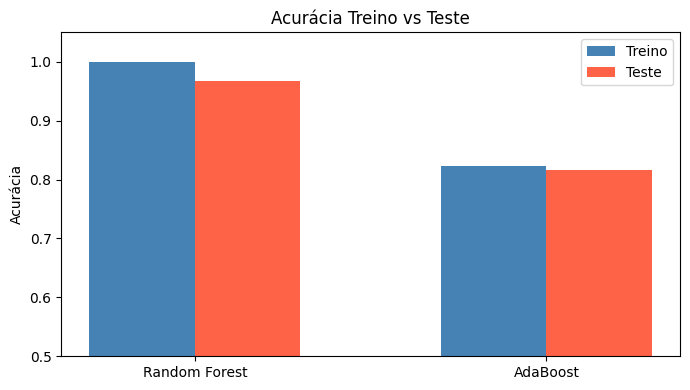

In [11]:
# TODO: implemente load_data

print("Análise de Overfitting — Treino vs Teste\n")
print(f"{'Modelo':>15} | {'Treino':>8} | {'Teste':>8} | {'Gap':>8}")
print("-" * 46)

for model_name, model in [("Random Forest", rf_model), ("AdaBoost", ab_model)]:
    acc_train = accuracy_score(y_train, model.predict(X_train))
    acc_test  = accuracy_score(y_test,  model.predict(X_test))
    gap = acc_train - acc_test
    print(f"{model_name:>15} | {acc_train:>8.4f} | {acc_test:>8.4f} | {gap:>8.4f}")

models_names = ['Random Forest', 'AdaBoost']
train_accs = [
    accuracy_score(y_train, rf_model.predict(X_train)),
    accuracy_score(y_train, ab_model.predict(X_train))
]
test_accs = [
    accuracy_score(y_test, rf_model.predict(X_test)),
    accuracy_score(y_test, ab_model.predict(X_test))
]

x = np.arange(len(models_names))
width = 0.3

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - width/2, train_accs, width, label='Treino', color='steelblue')
ax.bar(x + width/2, test_accs,  width, label='Teste',  color='tomato')
ax.set_xticks(x)
ax.set_xticklabels(models_names)
ax.set_ylim(0.5, 1.05)
ax.set_ylabel('Acurácia')
ax.set_title('Acurácia Treino vs Teste')
ax.legend()
plt.tight_layout()
plt.show()

# Questão 8

Varie pelo menos um hiperparâmetro em cada modelo:

- Random Forest: `n_estimators`
- AdaBoost: `n_estimators`

## Analise:
- O desempenho muda significativamente?

Os dois modelos respondem de forma muito diferente ao aumento de n_estimators. O Random Forest já começa com desempenho alto (94,56% com apenas 10 árvores) e cresce de forma gradual e estável até 96,81% com 200 árvores — uma variação total de apenas 2,25 pontos percentuais. O gráfico mostra uma curva quase plana, indicando que o RF converge rapidamente e ganhos adicionais são marginais.O AdaBoost apresenta variação muito mais expressiva: parte de 63,20% com 10 estimadores e chega a 82,71% com 200 — uma diferença de 19,51 pontos percentuais. O salto mais abrupto ocorre entre 10 e 50 estimadores, e a curva ainda está subindo, sugerindo que mais estimadores continuariam melhorando o desempenho.

## Responda:
- Qual modelo é mais sensível a mudanças?

O AdaBoost é claramente o modelo mais sensível a mudanças em n_estimators. Com poucos estimadores ele tem desempenho muito baixo, pois o algoritmo boosting constrói o modelo de forma incremental — cada estimador corrige os erros do anterior, então ter poucos limita muito a capacidade do modelo. O Random Forest, por outro lado, já com 10 árvores captura boa parte dos padrões do dataset, pois cada árvore é treinada de forma independente e o ensemble estabiliza rapidamente.

  n_estimators |  RF Acurácia |  AB Acurácia
--------------------------------------------
            10 |       0.9456 |       0.6320
            50 |       0.9639 |       0.7926
           100 |       0.9673 |       0.8156
           200 |       0.9681 |       0.8271


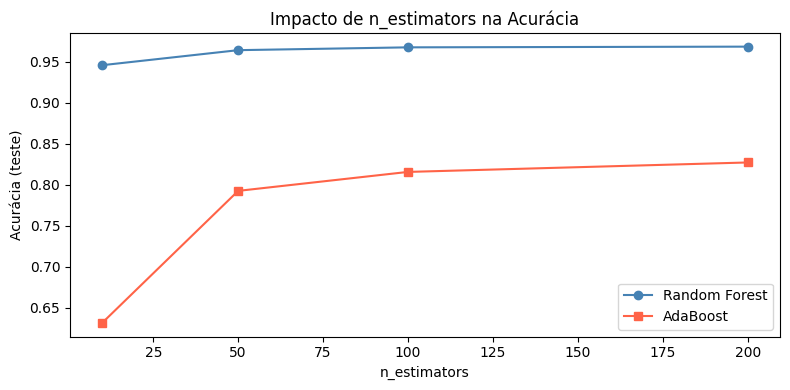

In [13]:
# TODO: implemente load_data

n_estimators_list = [10, 50, 100, 200]
seed = 42

X_train_q8, X_test_q8, y_train_q8, y_test_q8 = load_data(seed=seed)

rf_accs = []
ab_accs = []

print(f"{'n_estimators':>14} | {'RF Acurácia':>12} | {'AB Acurácia':>12}")
print("-" * 44)

for n in n_estimators_list:
    rf = RandomForestClassifier(n_estimators=n, random_state=seed, n_jobs=-1)
    rf.fit(X_train_q8, y_train_q8)
    acc_rf_n = accuracy_score(y_test_q8, rf.predict(X_test_q8))
    rf_accs.append(acc_rf_n)

    ab = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=2, random_state=seed),
    n_estimators=n,
    random_state=seed
    )
    ab.fit(X_train_q8, y_train_q8)
    acc_ab_n = accuracy_score(y_test_q8, ab.predict(X_test_q8))
    ab_accs.append(acc_ab_n)

    print(f"{n:>14} | {acc_rf_n:>12.4f} | {acc_ab_n:>12.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(n_estimators_list, rf_accs, 'o-', label='Random Forest', color='steelblue')
ax.plot(n_estimators_list, ab_accs, 's-', label='AdaBoost',      color='tomato')
ax.set_xlabel('n_estimators')
ax.set_ylabel('Acurácia (teste)')
ax.set_title('Impacto de n_estimators na Acurácia')
ax.legend()
plt.tight_layout()
plt.show()

# Questão 9

Responda (máx. 2 parágrafos por item):

1. A acurácia é suficiente para avaliar os modelos?

Não, a acurácia sozinha é insuficiente. O classification report do Random Forest mostra que o modelo tem desempenho equilibrado entre todas as classes (F1 entre 0,95 e 0,99), o que a acurácia global de 97% representa bem neste caso. Porém, em cenários com classes desbalanceadas, um modelo poderia ter alta acurácia simplesmente priorizando as classes majoritárias. Métricas como precisão, recall e F1-Score por classe são essenciais para identificar onde o modelo erra — por exemplo, o dígito 8 teve o menor recall (0,95) no RF, informação que a acurácia global mascara.

2. Como você garante que o resultado não ocorreu por acaso?

A principal garantia é o uso de random_state fixo em todas as etapas, que assegura que o resultado é determinístico e reprodutível — não uma flutuação aleatória. Adicionalmente, o teste com múltiplas seeds (42, 7, 123) mostrou que o RF consistentemente supera o AdaBoost em todas as execuções, o que indica que a diferença de desempenho é real e não fruto de uma divisão favorável dos dados. Para maior rigor, o ideal seria aplicar validação cruzada (k-fold) e calcular intervalos de confiança nas métricas.

3. Cite dois possíveis problemas metodológicos neste experimento.

Primeiro, o uso de split único treino/teste: toda a avaliação se baseia em uma única divisão dos dados, o que significa que os resultados podem ser influenciados pela sorte dessa partição específica. Validação cruzada estratificada corrigiria isso. Segundo, ausência de busca sistemática de hiperparâmetros: os modelos foram avaliados com configurações padrão ou variações manuais limitadas, sem GridSearch ou RandomSearch. Isso significa que os resultados apresentados não representam o potencial máximo dos modelos, tornando a comparação entre RF e AdaBoost parcialmente injusta.

4. O pipeline implementado é confiável? Justifique.

O pipeline é moderadamente confiável. Os pontos positivos são: reprodutibilidade garantida via random_state, ausência de data leakage (o split é feito antes de qualquer transformação), e avaliação em dados nunca vistos pelo modelo. As limitações são: uso de split único sem cross-validation, sem normalização explicitamente justificada para cada modelo, e a análise de hiperparâmetros foi exploratória e não exaustiva. Para um experimento científico rigoroso, seria necessário adicionar validação cruzada estratificada e intervalos de confiança, mas para os objetivos desta atividade o pipeline cumpre os requisitos de correção, reprodutibilidade e estrutura.

In [14]:
# TODO: implemente load_data

print("=" * 55)
print(" Classification Report — Random Forest")
print("=" * 55)
print(classification_report(y_test, rf_model.predict(X_test)))

print("=" * 55)
print(" Classification Report — AdaBoost")
print("=" * 55)
print(classification_report(y_test, ab_model.predict(X_test)))

 Classification Report — Random Forest
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1343
           1       0.98      0.98      0.98      1600
           2       0.95      0.97      0.96      1380
           3       0.96      0.95      0.96      1433
           4       0.96      0.97      0.97      1295
           5       0.97      0.96      0.97      1273
           6       0.98      0.98      0.98      1396
           7       0.97      0.97      0.97      1503
           8       0.96      0.95      0.96      1357
           9       0.96      0.95      0.95      1420

    accuracy                           0.97     14000
   macro avg       0.97      0.97      0.97     14000
weighted avg       0.97      0.97      0.97     14000

 Classification Report — AdaBoost
              precision    recall  f1-score   support

           0       0.95      0.84      0.89      1343
           1       0.91      0.94      0.93      1600
     